# Importing Kaggle dataset

In [1]:
import kagglehub
path = kagglehub.dataset_download("jakewright/house-price-data")

100%|██████████| 48.5M/48.5M [00:00<00:00, 92.1MB/s]

Extracting files...


# Importing dependencies and library

In [52]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


# Loading dataset

In [3]:
os.listdir(path)

['kaggle_london_house_price_data.csv',
 'kaggle_london_house_price_data.parquet']

On this dataset we get Kaggle dataset link we have two file one is csv and parquet 'kaggle_london_house_price_data.csv' and 'kaggle_london_house_price_data.parquet' both dataset have the same number of columns and features all the value are same but size is different so On this project i used the parquet dataset because lingt weight and suitable for large dataset.

In [4]:
data_csv = os.path.join(path, 'kaggle_london_house_price_data.csv')

In [5]:
data_parquet = os.path.join(path, 'kaggle_london_house_price_data.parquet')

In [6]:
df_csv = pd.read_csv(data_csv)

In [7]:
df_parquet = pd.read_parquet(data_parquet)

# Exploratory Data Analysis

## Understading of dataset

In [8]:
df_csv.shape

(418201, 28)

In [9]:
df_parquet.shape

(418201, 28)

In [10]:
df_csv.head()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


In [11]:
df_parquet.head()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


In [12]:
df_parquet.tail()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
418196,"9 Harvard Road, London, SE13 6SE",SE13 6SE,England,SE13,51.452919,-0.010221,2.0,3.0,123.0,2.0,...,711000.0,HIGH,2025-01-10T11:04:57.114Z,27000.0,4.153846,2024-09-27,2024-09-27,650000,17.117117,95000.0
418197,"Lower Ground Floor Flat 5, Northwood Hall, Hor...",N6 5PE,England,N6,51.571692,-0.137007,1.0,2.0,60.0,1.0,...,473000.0,HIGH,2025-01-10T11:04:57.114Z,10000.0,2.272727,2024-09-27,2024-09-27,440000,2.325581,10000.0
418198,"17 Merritt Road, London, SE4 1DU",SE4 1DU,England,SE4,51.456054,-0.035073,2.0,3.0,100.0,1.0,...,853000.0,HIGH,2025-01-10T11:04:57.114Z,38000.0,4.909561,2024-09-27,2024-09-27,774000,128.655835,435500.0
418199,"15 Chester Row, London, SW1W 9JF",SW1W 9JF,England,SW1W,51.493587,-0.152122,3.0,4.0,218.0,2.0,...,5975000.0,MEDIUM,2025-01-10T11:04:57.114Z,-818000.0,-13.088000,2024-09-27,2024-09-27,6250000,73.611111,2650000.0
418200,"56 Whiteley Road, London, SE19 1JT",SE19 1JT,England,SE19,51.424412,-0.090256,1.0,5.0,154.0,2.0,...,1031000.0,HIGH,2025-01-10T11:04:57.114Z,55000.0,5.876011,2024-09-27,2024-09-27,927500,692.735043,810500.0


In [13]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                418201 non-null  object 
 1   postcode                                   418201 non-null  object 
 2   country                                    418201 non-null  object 
 3   outcode                                    418201 non-null  object 
 4   latitude                                   418201 non-null  float64
 5   longitude                                  418201 non-null  float64
 6   bathrooms                                  340270 non-null  float64
 7   bedrooms                                   377665 non-null  float64
 8   floorAreaSqM                               392991 non-null  float64
 9   livingRooms                                357701 non-null  float64
 10  tenure  

In [14]:
df_parquet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                418201 non-null  object 
 1   postcode                                   418201 non-null  object 
 2   country                                    418201 non-null  object 
 3   outcode                                    418201 non-null  object 
 4   latitude                                   418201 non-null  float64
 5   longitude                                  418201 non-null  float64
 6   bathrooms                                  340270 non-null  float64
 7   bedrooms                                   377665 non-null  float64
 8   floorAreaSqM                               392991 non-null  float64
 9   livingRooms                                357701 non-null  float64
 10  tenure  

### Converting date time

In [15]:
cols = [
    'saleEstimate_ingestedAt',
    'saleEstimate_valueChange.saleDate',
    'history_date'
]

for col in cols:
    print(f"{col}: ")
    print("Sample values:")
    print(df_parquet[col].head(10))
    print("\nUnique sample values:")
    print(df_parquet[col].dropna().unique()[:10])

saleEstimate_ingestedAt: 
Sample values:
0    2024-10-07T13:26:59.894Z
1    2024-10-07T13:26:59.894Z
2    2025-01-10T11:04:57.114Z
3    2024-10-07T13:26:59.894Z
4    2024-10-07T13:26:59.894Z
5    2024-10-07T13:26:59.894Z
6    2024-10-07T13:26:59.894Z
7    2025-01-10T11:04:57.114Z
8    2024-10-07T13:26:59.894Z
9    2025-01-10T11:04:57.114Z
Name: saleEstimate_ingestedAt, dtype: object

Unique sample values:
['2024-10-07T13:26:59.894Z' '2025-01-10T11:04:57.114Z'
 '2025-02-06T14:05:28.374Z' '2024-11-05T11:25:48.799Z']
saleEstimate_valueChange.saleDate: 
Sample values:
0    2010-03-30
1    2000-05-26
2    2019-09-04
3    2024-01-25
4    2022-12-14
5    2021-09-30
6    2021-12-06
7    2016-09-27
8    2022-02-10
9    2022-12-14
Name: saleEstimate_valueChange.saleDate, dtype: object

Unique sample values:
['2010-03-30' '2000-05-26' '2019-09-04' '2024-01-25' '2022-12-14'
 '2021-09-30' '2021-12-06' '2016-09-27' '2022-02-10' '2024-04-19']
history_date: 
Sample values:
0    1995-01-02
1    1995-01

In [16]:
df_parquet['saleEstimate_ingestedAt'] = pd.to_datetime(df_parquet['saleEstimate_ingestedAt'], errors='coerce')
df_parquet['saleEstimate_valueChange.saleDate'] = pd.to_datetime(df_parquet['saleEstimate_valueChange.saleDate'], errors='coerce')
df_parquet['history_date'] = pd.to_datetime(df_parquet['history_date'], errors='coerce')

In [17]:
df_parquet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype              
---  ------                                     --------------   -----              
 0   fullAddress                                418201 non-null  object             
 1   postcode                                   418201 non-null  object             
 2   country                                    418201 non-null  object             
 3   outcode                                    418201 non-null  object             
 4   latitude                                   418201 non-null  float64            
 5   longitude                                  418201 non-null  float64            
 6   bathrooms                                  340270 non-null  float64            
 7   bedrooms                                   377665 non-null  float64            
 8   floorAreaSqM                      

### Missing values analysis

In [18]:
df_parquet.isnull().sum()

,0
fullAddress,0
postcode,0
country,0
outcode,0
latitude,0
longitude,0
bathrooms,77931
bedrooms,40536
floorAreaSqM,25210
livingRooms,60500


'fullAddress' is droped because it does not need us.

In [19]:
df_parquet.drop(columns=['fullAddress'], inplace=True)

In [20]:
missing = df_parquet.isnull().sum().sort_values(ascending=False)
missing_percent = (df_parquet.isnull().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print(missing_df)

                                           Missing Count  Missing %
history_numericChange                             180219  43.093871
history_percentageChange                          180219  43.093871
currentEnergyRating                                84526  20.211812
bathrooms                                          77931  18.634819
livingRooms                                        60500  14.466728
bedrooms                                           40536   9.692947
floorAreaSqM                                       25210   6.028202
tenure                                             11512   2.752743
rentEstimate_lowerPrice                             1741   0.416307
rentEstimate_upperPrice                             1741   0.416307
rentEstimate_currentPrice                           1741   0.416307
propertyType                                        1136   0.271640
saleEstimate_confidenceLevel                         640   0.153036
saleEstimate_ingestedAt                         

## Descriptive Analysis

In [21]:
df_parquet.describe()

,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,rentEstimate_lowerPrice,rentEstimate_currentPrice,rentEstimate_upperPrice,saleEstimate_lowerPrice,saleEstimate_currentPrice,saleEstimate_upperPrice,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
count,418201.000000,418201.000000,340270.000000,377665.000000,392991.000000,357701.000000,416460.000000,416460.000000,416460.000000,4.175610e+05,4.175610e+05,4.175610e+05,4.175610e+05,417561.000000,417561,418201,4.182010e+05,237982.000000,2.379820e+05
mean,51.507522,-0.101426,1.444265,2.474884,98.926543,1.282275,3299.054171,3639.487466,3980.117298,8.312692e+05,9.045188e+05,9.777633e+05,2.886077e+04,29.278605,2021-11-27 12:28:40.195132928,2013-08-27 20:59:16.846587904,6.395840e+05,105.877778,2.528741e+05
min,51.385708,-0.347055,1.000000,1.000000,10.000000,1.000000,300.000000,350.000000,400.000000,8.100000e+04,8.900000e+04,9.300000e+04,-1.053770e+08,-99.763196,1995-01-06 00:00:00,1995-01-02 00:00:00,1.000000e+04,-99.890110,-7.390000e+07
25%,51.464315,-0.155996,1.000000,2.000000,63.000000,1.000000,1800.000000,1950.000000,2100.000000,4.160000e+05,4.460000e+05,4.750000e+05,1.100000e+04,2.105263,2021-07-08 00:00:00,2005-03-17 00:00:00,2.280000e+05,17.833333,4.849500e+04
50%,51.501581,-0.108482,1.000000,2.000000,84.000000,1.000000,2350.000000,2600.000000,2850.000000,5.810000e+05,6.220000e+05,6.630000e+05,3.500000e+04,6.260870,2022-11-30 00:00:00,2016-01-21 00:00:00,4.000000e+05,52.857143,1.300000e+05
75%,51.548515,-0.043582,2.000000,3.000000,116.000000,1.000000,3550.000000,3950.000000,4300.000000,9.130000e+05,9.840000e+05,1.054000e+06,8.600000e+04,13.554987,2023-10-04 00:00:00,2022-07-29 00:00:00,6.650000e+05,114.285714,2.870000e+05
max,51.665823,0.139249,9.000000,9.000000,500.000000,9.000000,111500.000000,121200.000000,130900.000000,2.337600e+07,2.922000e+07,3.506400e+07,2.268100e+07,48860.000000,2024-09-27 00:00:00,2024-09-27 00:00:00,1.058000e+08,48800.770000,6.382000e+07
std,0.056171,0.086930,0.724478,1.160506,55.938911,0.574412,3168.625404,3487.801945,3808.508868,8.088434e+05,9.202917e+05,1.037913e+06,1.080893e+06,362.350731,NaN,NaN,1.327933e+06,338.849944,8.024032e+05


In [22]:
df_parquet.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,418201.0,51.507522,51.385708,51.464315,51.501581,51.548515,51.665823,0.056171
longitude,418201.0,-0.101426,-0.347055,-0.155996,-0.108482,-0.043582,0.139249,0.08693
bathrooms,340270.0,1.444265,1.0,1.0,1.0,2.0,9.0,0.724478
bedrooms,377665.0,2.474884,1.0,2.0,2.0,3.0,9.0,1.160506
floorAreaSqM,392991.0,98.926543,10.0,63.0,84.0,116.0,500.0,55.938911
livingRooms,357701.0,1.282275,1.0,1.0,1.0,1.0,9.0,0.574412
rentEstimate_lowerPrice,416460.0,3299.054171,300.0,1800.0,2350.0,3550.0,111500.0,3168.625404
rentEstimate_currentPrice,416460.0,3639.487466,350.0,1950.0,2600.0,3950.0,121200.0,3487.801945
rentEstimate_upperPrice,416460.0,3980.117298,400.0,2100.0,2850.0,4300.0,130900.0,3808.508868
saleEstimate_lowerPrice,417561.0,831269.215755,81000.0,416000.0,581000.0,913000.0,23376000.0,808843.379724


# Save file for visualization.

In [23]:
save_dir = Path("../data")
save_dir.mkdir(parents=True, exist_ok=True)

save_path = save_dir / "house_price_data.csv"

df_parquet.to_csv(save_path, index=False)

print("Saved to:", save_path.resolve())

Saved to: /data/house_price_data.csv


# The visualization part is done using powerbi. You can acces dashboard from powerbi folder section of house-price-analysis-sql-powerbi-ml folder.

# Cleaning the dataset

## removing unneccesory columns.

In [24]:
drop_cols = [
    'country',
    'rentEstimate_lowerPrice',
    'rentEstimate_currentPrice',
    'rentEstimate_upperPrice',
    'history_numericChange',
    'history_percentageChange',
    'postcode',
    'saleEstimate_confidenceLevel',
    'saleEstimate_ingestedAt',
    'saleEstimate_valueChange.numericChange',
    'saleEstimate_valueChange.saleDate',
    'saleEstimate_upperPrice',
    'saleEstimate_lowerPrice',
    'saleEstimate_currentPrice',
    'saleEstimate_valueChange.percentageChange'
]

In [25]:
df_parquet.drop(columns=drop_cols, inplace=True, errors='ignore')

In [26]:
for i in df_parquet.columns:
  print(i)

outcode
latitude
longitude
bathrooms
bedrooms
floorAreaSqM
livingRooms
tenure
propertyType
currentEnergyRating
history_date
history_price


# Feature Engineering

In [27]:
df_parquet['history_date'] = pd.to_datetime(df_parquet['history_date'], errors='coerce')

df_parquet['sale_year'] = df_parquet['history_date'].dt.year
df_parquet['sale_month'] = df_parquet['history_date'].dt.month

df_parquet['years_since_sale'] = ((pd.Timestamp.today() - df_parquet['history_date']).dt.days / 365.25).round(1)

df_parquet = df_parquet.drop(columns=['history_date'], errors='ignore')

In [28]:
for i in df_parquet.columns:
  print(i)

outcode
latitude
longitude
bathrooms
bedrooms
floorAreaSqM
livingRooms
tenure
propertyType
currentEnergyRating
history_price
sale_year
sale_month
years_since_sale


# Pre-processing

In [29]:
# target and features
X = df_parquet.drop(columns=['history_price'])
y = df_parquet['history_price']

In [30]:
# columns groups
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [31]:
# preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [32]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Train test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

# Model Training

## Random Forest

In [34]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

In [51]:
model.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

## Linear Regression

In [36]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [37]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'bathrooms', 'bedrooms',
                                                   'floorAreaSqM',
                                                   'livingRooms',
                                                   'years_since_sale']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['outcode', 'tenure',
                                                   'propertyType',
                                                   'currentEnergyRating'])])),
                ('model', LinearRegression())])

In [38]:
y_pred_linear = linear_model.predict(X_test)

In [39]:
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

In [40]:
print("Linear Regression Results")
print("MAE:", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R2:", round(linear_r2, 4))

Linear Regression Results
MAE: 336379.62
RMSE: 1173844.4
R2: 0.2576


## Gradient Boosting

In [41]:
gradient_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

In [42]:
gradient_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'bathrooms', 'bedrooms',
                                                   'floorAreaSqM',
                                                   'livingRooms',
                                                   'years_since_sale']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['outcode', 'tenure',
                                                   'propertyType',
                                                   'currentEnergyRating'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [43]:
y_pred_gradient = gradient_model.predict(X_test)

In [44]:
gradient_mae = mean_absolute_error(y_test, y_pred_gradient)
gradient_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gradient))
gradient_r2 = r2_score(y_test, y_pred_gradient)

In [45]:
print("Gradient Boosting Results")
print("MAE:", round(gradient_mae, 2))
print("RMSE:", round(gradient_rmse, 2))
print("R2:", round(gradient_r2, 4))

Gradient Boosting Results
MAE: 236865.28
RMSE: 1058854.55
R2: 0.3959


In [50]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression', 'Gradient Boosting'],
    'MAE': [mae if 'mae' in locals() else np.nan, linear_mae, gradient_mae],
    'RMSE': [rmse if 'rmse' in locals() else np.nan, linear_rmse, gradient_rmse],
    'R2 Score': [r2 if 'r2' in locals() else np.nan, linear_r2, gradient_r2]
})

# Sort by R2 Score and display plain dataframe
results_sorted = results.sort_values(by='R2 Score', ascending=False)
display(results_sorted)

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,236865.275911,1.058855e+06,0.395895
1,Linear Regression,336379.624293,1.173844e+06,0.257561
0,Random Forest,NaN,NaN,NaN


# Now Build the model using Neural Network

## neural networks work better when data scaled, we use log transformation for y_train and y_test.

In [53]:
# Log transform target variable
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

House prices are usually not evenly distributed. Some houses are cheap, some are extremely expensive. This can make training harder. np.log1p() This changes the target price into a smaller, smoother scale.

In [54]:
# preprocessing to features
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

preprocessor converts every num cat columns to numbers.

In [56]:
X_test_nn_df = pd.DataFrame(X_test_nn.toarray() if hasattr(X_test_nn, 'toarray') else X_test_nn)
X_test_nn_df.head()

,0,1,2,3,4,5,6,7,8,9,...,198,199,200,201,202,203,204,205,206,207
0,1.777878,-0.344495,0.945654,1.411593,1.176184,1.400634,-1.051360,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.891747,-1.359611,0.945654,-0.386951,-0.405562,-0.446487,-1.094333,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.191410,-0.558189,-0.534976,0.512321,0.072640,1.400634,-0.836490,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.550670,1.973631,-0.534976,0.512321,-0.258423,1.400634,-1.083590,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-1.255791,-0.401049,-0.534976,-0.386951,-0.240031,-0.446487,1.301465,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


the preprocessor converts everythings to number and this can make like this:<br>
Numerical data → fills missing values + scales values<br>
Categorical data → fills missing values + one-hot encoding

In [ ]:
# Convert sparse matrix to dense array if needed
if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()
    X_test_nn = X_test_nn.toarray()


Sometimes one-hot encoding creates a sparse matrix. TensorFlow works better with normal arrays, so this converts it.

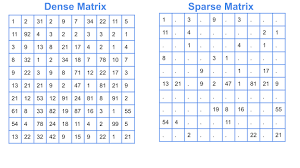

In [57]:

# Convert to float32 for TensorFlow
X_train_nn = X_train_nn.astype("float32")
X_test_nn = X_test_nn.astype("float32")

print("Training shape:", X_train_nn.shape)
print("Testing shape:", X_test_nn.shape)

Training shape: (334560, 208)
Testing shape: (83641, 208)


## Build Neural Network model

In [58]:
input_dim = X_train_nn.shape[1]

nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.1),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dense(256, activation='relu')<br>
This is a hidden layer with 256 neurons.ReLU is the activation function. It helps the model learn non-linear patterns.<br>
BatchNormalization()
This helps stabilise training. It makes learning smoother and faster.<br>
Dropout(0.3)
Dropout randomly switches off some neurons during training.<br>
Dense(1)
The final layer has one neuron because we are predicting one value:<br>
house price

In [59]:
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        53,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,257 (376.00 KB)

 Trainable params: 95,489 (373.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [61]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_nn,
    y_train_log,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 6.1933 - mae: 1.6312 - val_loss: 0.3443 - val_mae: 0.4348
Epoch 2/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 1.8398 - mae: 1.0705 - val_loss: 0.2366 - val_mae: 0.3495
Epoch 3/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.4654 - mae: 0.9549 - val_loss: 0.1844 - val_mae: 0.2943
Epoch 4/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 1.2078 - mae: 0.8634 - val_loss: 0.2348 - val_mae: 0.3463
Epoch 5/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - loss: 1.0174 - mae: 0.7899 - val_loss: 0.1769 - val_mae: 0.2802
Epoch 6/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.8467 - mae: 0.7163 - val_loss: 0.1649 - val_mae: 0.2723
Epoch 7/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.7127 - mae: 0.6528 - val_loss: 0.1739 - val_mae: 0.2784
Epoch 8/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.6154 - mae: 0.6030 - val_loss: 0.1959 - val_mae: 0.2752
Epoch 9/100
1046/1046 ━━━━━

## Evaluation the NN model

In [62]:
# Predict log prices
y_pred_nn_log = nn_model.predict(X_test_nn).flatten()

# Convert predictions back to actual price
y_pred_nn = np.expm1(y_pred_nn_log)

# Actual y_test is already original price
y_test_actual = y_test

# Evaluation
nn_mae = mean_absolute_error(y_test_actual, y_pred_nn)
nn_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_nn))
nn_r2 = r2_score(y_test_actual, y_pred_nn)

print("Neural Network Results")
print("MAE:", round(nn_mae, 2))
print("RMSE:", round(nn_rmse, 2))
print("R2:", round(nn_r2, 4))

2614/2614 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Neural Network Results
MAE: 183756.98
RMSE: 1782354.22
R2: -0.7117


## Plot Neural Network training loss

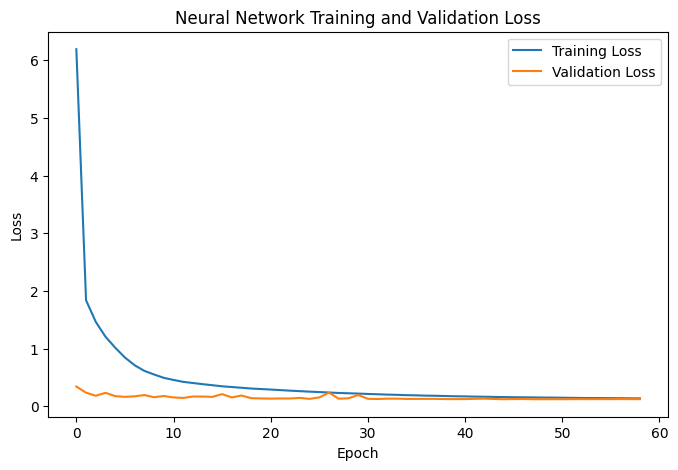

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training and Validation Loss')
plt.legend()
plt.show()

# Compare all models

## Random Forest:  mae, rmse, r2
## Linear Regression: linear_mae, linear_rmse, linear_r2
## Gradient Boosting: gradient_mae, gradient_rmse, gradient_r2
## Neural Network:  nn_mae, nn_rmse, nn_r2

In [65]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Linear Regression',
        'Gradient Boosting',
        'Neural Network'
    ],
    'MAE': [
        mae if 'mae' in locals() else np.nan,
        linear_mae,
        gradient_mae,
        nn_mae
    ],
    'RMSE': [
        rmse if 'rmse' in locals() else np.nan,
        linear_rmse,
        gradient_rmse,
        nn_rmse
    ],
    'R2 Score': [
        r2 if 'r2' in locals() else np.nan,
        linear_r2,
        gradient_r2,
        nn_r2
    ]
})

results_sorted = results.sort_values(by='R2 Score', ascending=False)
display(results_sorted)

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,236865.275911,1.058855e+06,0.395895
1,Linear Regression,336379.624293,1.173844e+06,0.257561
3,Neural Network,183756.984375,1.782354e+06,-0.711701
0,Random Forest,NaN,NaN,NaN


A neural network regression model was developed to predict London house prices. The existing cleaned dataset and train-test split were used. Numerical features were scaled and categorical features were encoded using the existing preprocessing pipeline. The target variable was transformed using log1p because house prices are usually highly skewed. The neural network included dense layers, batch normalization, and dropout to reduce overfitting. The model was evaluated using MAE, RMSE, and R² score, then compared with Random Forest, Linear Regression, and Gradient Boosting.

## Identify and Visualize Outliers

### Subtask:
Analyze the 'history_price' and 'floorAreaSqM' columns to identify and quantify extreme outliers in the dataset.


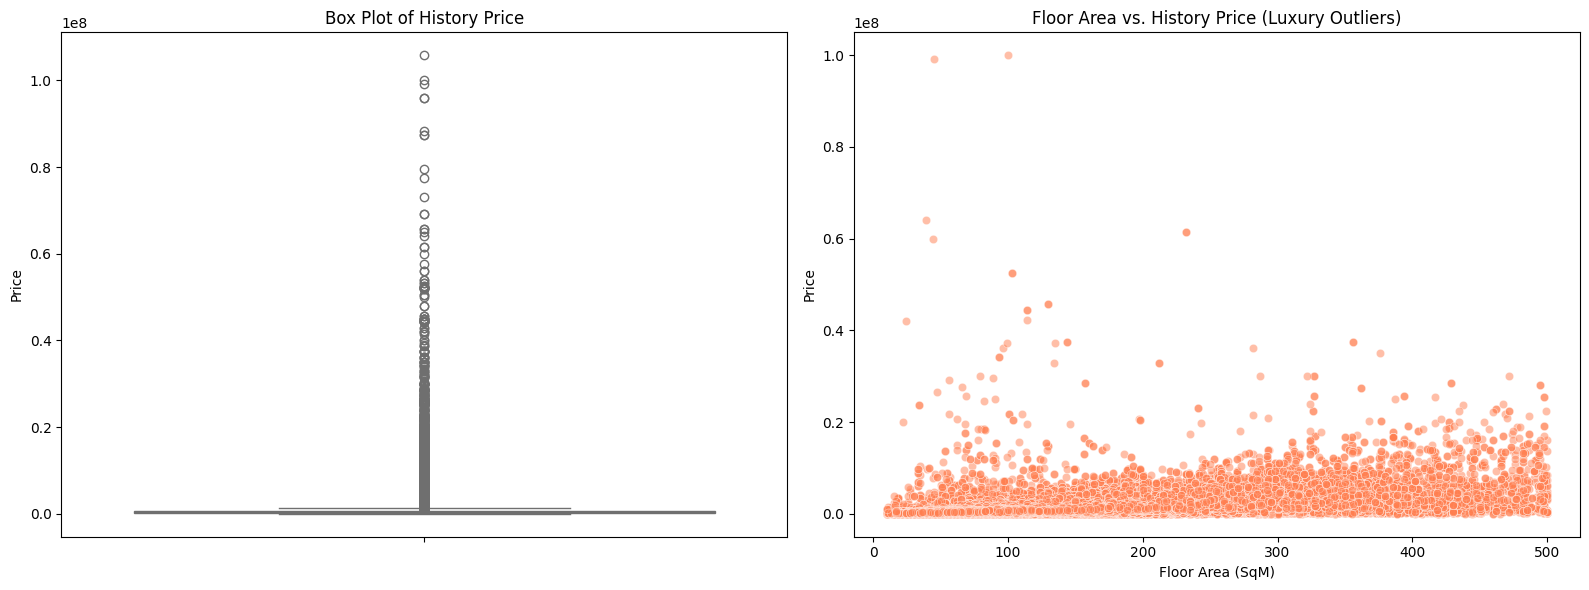

--- Outlier Analysis for history_price ---
IQR Upper Bound: 1,320,500.00
Number of outliers (IQR): 34699
Percentage of dataset (IQR): 8.30%
Number of outliers (Z-score > 3): 4060

Summary Statistics of IQR Outliers:
       history_price  floorAreaSqM
count   3.469900e+04  31317.000000
mean    2.989074e+06    193.038861
std     3.789999e+06     85.297971
min     1.321000e+06     11.000000
25%     1.560000e+06    129.000000
50%     1.950000e+06    178.000000
75%     3.000000e+06    241.000000
max     1.058000e+08    500.000000


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot for history_price
sns.boxplot(y=df_parquet['history_price'], ax=ax1, color='skyblue')
ax1.set_title('Box Plot of History Price')
ax1.set_ylabel('Price')

# Scatter plot for floorAreaSqM vs history_price
sns.scatterplot(x='floorAreaSqM', y='history_price', data=df_parquet, ax=ax2, alpha=0.5, color='coral')
ax2.set_title('Floor Area vs. History Price (Luxury Outliers)')
ax2.set_xlabel('Floor Area (SqM)')
ax2.set_ylabel('Price')

plt.tight_layout()
plt.show()

# 3. IQR Calculation for history_price
Q1 = df_parquet['history_price'].quantile(0.25)
Q3 = df_parquet['history_price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_parquet[df_parquet['history_price'] > upper_bound]
count_iqr = len(outliers_iqr)
percent_iqr = (count_iqr / len(df_parquet)) * 100

# 4. Z-score Calculation
z_scores = stats.zscore(df_parquet['history_price'])
outliers_z = df_parquet[abs(z_scores) > 3]
count_z = len(outliers_z)

# 5. Print Summary
print(f"--- Outlier Analysis for history_price ---")
print(f"IQR Upper Bound: {upper_bound:,.2f}")
print(f"Number of outliers (IQR): {count_iqr}")
print(f"Percentage of dataset (IQR): {percent_iqr:.2f}%")
print(f"Number of outliers (Z-score > 3): {count_z}")
print("\nSummary Statistics of IQR Outliers:")
print(outliers_iqr[['history_price', 'floorAreaSqM']].describe())


### Outlier Identification and Quantification
We will use the Interquartile Range (IQR) method to identify extreme values in property prices and floor areas.

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a helper to calculate outliers
def get_outliers_info(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyze history_price
price_outliers, p_low, p_high = get_outliers_info(df_parquet, 'history_price')

print(f"--- Outlier Analysis: history_price ---")
print(f"Lower Bound: {p_low:,.2f}")
print(f"Upper Bound: {p_high:,.2f}")
print(f"Total Outliers: {len(price_outliers)}")
print(f"Percentage of Outliers: {(len(price_outliers)/len(df_parquet))*100:.2f}%")
print(f"Max Price in Data: {df_parquet['history_price'].max():,.2f}")

--- Outlier Analysis: history_price ---
Lower Bound: -427,500.00
Upper Bound: 1,320,500.00
Total Outliers: 34699
Percentage of Outliers: 8.30%
Max Price in Data: 105,800,000.00


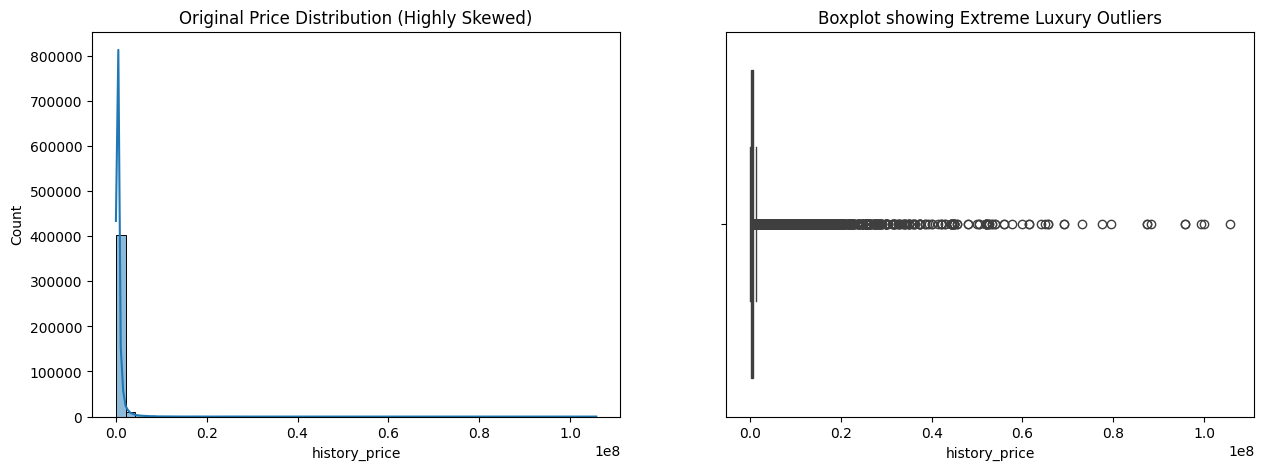

In [69]:
# Visualizing the distribution with and without outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_parquet['history_price'], bins=50, ax=axes[0], kde=True)
axes[0].set_title('Original Price Distribution (Highly Skewed)')

sns.boxplot(x=df_parquet['history_price'], ax=axes[1])
axes[1].set_title('Boxplot showing Extreme Luxury Outliers')

plt.show()

### Outlier Mitigation: Winsorization
We will cap the `history_price` at the 99th percentile to prevent extreme luxury prices from dominating the loss function.

In [71]:
from scipy.stats.mstats import winsorize

# Cap outliers at the 99th percentile
df_capped = df_parquet.copy()
# Applying capping to the top 1% of values
upper_limit = df_capped['history_price'].quantile(0.99)
df_capped['history_price'] = df_capped['history_price'].clip(upper=upper_limit)

print(f"New Maximum Price after capping: {df_capped['history_price'].max():,.2f}")

# Re-prepare target and features with capped data
X_capped = df_capped.drop(columns=['history_price'])
y_capped = df_capped['history_price']

# Split again
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_capped, y_capped, test_size=0.2, random_state=42)

# Log transform the capped target
y_train_c_log = np.log1p(y_train_c)
y_test_c_log = np.log1p(y_test_c)

# Preprocess features
X_train_c_nn = preprocessor.fit_transform(X_train_c)
X_test_c_nn = preprocessor.transform(X_test_c)

if hasattr(X_train_c_nn, 'toarray'):
    X_train_c_nn = X_train_c_nn.toarray().astype('float32')
    X_test_c_nn = X_test_c_nn.toarray().astype('float32')

print("Data re-prepared with capped outliers.")

New Maximum Price after capping: 4,500,000.00
Data re-prepared with capped outliers.


### Re-training Neural Network on Capped Data
With the outliers capped at £4.5M, we re-run the training process to achieve a more meaningful R2 score.

In [72]:
# Re-build and re-train the model with capped data
input_dim = X_train_c_nn.shape[1]

nn_model_capped = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

nn_model_capped.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Neural Network on capped data...")
history_capped = nn_model_capped.fit(
    X_train_c_nn, y_train_c_log,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
y_pred_nn_capped_log = nn_model_capped.predict(X_test_c_nn).flatten()
y_pred_nn_capped = np.expm1(y_pred_nn_capped_log)

nn_c_mae = mean_absolute_error(y_test_c, y_pred_nn_capped)
nn_c_rmse = np.sqrt(mean_squared_error(y_test_c, y_pred_nn_capped))
nn_c_r2 = r2_score(y_test_c, y_pred_nn_capped)

print(f"\nCapped Neural Network Results:")
print(f"MAE: {nn_c_mae:,.2f}")
print(f"R2 Score: {nn_c_r2:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network on capped data...
2614/2614 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Capped Neural Network Results:
MAE: 134,782.42
R2 Score: 0.7850


# Training the model deleting outliers

In [73]:
# Remove extremely high property prices above £10 million
df_nn = df_parquet[df_parquet['history_price'] <= 10000000].copy()

print("Original dataset shape:", df_parquet.shape)
print("Dataset shape after removing extreme prices:", df_nn.shape)
print("Rows removed:", df_parquet.shape[0] - df_nn.shape[0])

Original dataset shape: (418201, 14)
Dataset shape after removing extreme prices: (417191, 14)
Rows removed: 1010


In [74]:
X = df_nn.drop(columns=['history_price'])
y = df_nn['history_price']

In [74]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [75]:
X_train_nn = preprocessor.fit_transform(X_train)
X_test_nn = preprocessor.transform(X_test)

if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()
    X_test_nn = X_test_nn.toarray()

X_train_nn = X_train_nn.astype("float32")
X_test_nn = X_test_nn.astype("float32")

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_dim = X_train_nn.shape[1]

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [77]:
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

nn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        26,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,889 (148.00 KB)

 Trainable params: 37,505 (146.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [78]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

history = nn_model.fit(
    X_train_nn,
    y_train_log,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 2.4527 - mae: 2.8999 - val_loss: 0.1175 - val_mae: 0.3570 - learning_rate: 5.0000e-04
Epoch 2/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.0580 - mae: 1.4862 - val_loss: 0.1084 - val_mae: 0.3484 - learning_rate: 5.0000e-04
Epoch 3/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.8751 - mae: 1.2926 - val_loss: 0.0995 - val_mae: 0.3327 - learning_rate: 5.0000e-04
Epoch 4/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.7189 - mae: 1.1249 - val_loss: 0.0830 - val_mae: 0.2965 - learning_rate: 5.0000e-04
Epoch 5/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.6095 - mae: 1.0048 - val_loss: 0.0810 - val_mae: 0.2897 - learning_rate: 5.0000e-04
Epoch 6/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.5187 - mae: 0.9024 - val_loss: 0.0835 - val_mae: 0.2951 - learning_rate: 5.0000e-04
Epoch 7/100
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.4385 - mae: 0.8100 - val_loss: 0.0727 

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_nn_log = nn_model.predict(X_test_nn).flatten()

# Convert prediction back to original price scale
y_pred_nn = np.expm1(y_pred_nn_log)

# Evaluation
nn_mae = mean_absolute_error(y_test, y_pred_nn)
nn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
nn_r2 = r2_score(y_test, y_pred_nn)

print("Improved Neural Network Results")
print("MAE:", round(nn_mae, 2))
print("RMSE:", round(nn_rmse, 2))
print("R2:", round(nn_r2, 4))

2614/2614 ━━━━━━━━━━━━━━━━━━━━ 2s 902us/step
Improved Neural Network Results
MAE: 179551.67
RMSE: 1097619.46
R2: 0.3509


In [80]:
log_mae = mean_absolute_error(y_test_log, y_pred_nn_log)
log_rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_nn_log))
log_r2 = r2_score(y_test_log, y_pred_nn_log)

print("Log Scale Neural Network Results")
print("Log MAE:", round(log_mae, 4))
print("Log RMSE:", round(log_rmse, 4))
print("Log R2:", round(log_r2, 4))

Log Scale Neural Network Results
Log MAE: 0.2309
Log RMSE: 0.37
Log R2: 0.8407


The first neural network model produced an MAE of £183,756.98, RMSE of £1,782,354.22, and an R² score of -0.7117. The negative R² score shows that the neural network performed worse than a simple baseline model that predicts the average house price. This poor performance is likely caused by extreme outliers in the target variable, as the maximum recorded property price was £105.8 million. These high-value properties strongly affected the RMSE and made model learning unstable.

To improve the neural network, extreme luxury properties above £10 million were removed, while normal high-value London properties were retained. The target variable was still log-transformed to reduce skewness, and Huber loss was used instead of mean squared error because it is more robust to outliers. Early stopping and learning-rate reduction were also applied to reduce overfitting and improve model stability.